In [3]:
import numpy as np
def f(t, y):
    return y**2 - 10
def fprime(y):
    return 2 * y
def backward_euler_step(f, y, t, h, tol=1e-6, max_iter=50):
    y_next = y  
    for _ in range(max_iter):
        g_val = y_next - y - h * f(t + h, y_next)
        g_prime_val = 1 - h * fprime(y_next)
        if abs(g_prime_val) < tol:  
            break  
        y_new = y_next - g_val / g_prime_val 
        if abs(y_new - y_next) < tol: 
            return y_new  
        y_next = y_new  
    return y_next 
def backward_euler_adaptive(f, y0, t0, tf, h_init, tol=1e-6, max_iter=50):
    t_values = [t0] 
    y_values = [y0] 
    h = h_init 
    t = t0 
    y = y0 
    
    while t < tf: 
        if t + h > tf:  
            h = tf - t
        y_full = backward_euler_step(f, y, t, h, tol, max_iter) 
        h_half = h / 2 
        y_half_1 = backward_euler_step(f, y, t, h_half, tol, max_iter) 
        y_half_2 = backward_euler_step(f, y_half_1, t + h_half, h_half, tol, max_iter) 
        error = abs(y_full - y_half_2) 
        if error > tol: 
            h /= 2  
            continue  
        elif error < tol / 2: 
            h *= 2  
        t += h 
        y = y_half_2 
        t_values.append(t) 
        y_values.append(y) 
    return np.array(t_values), np.array(y_values) 

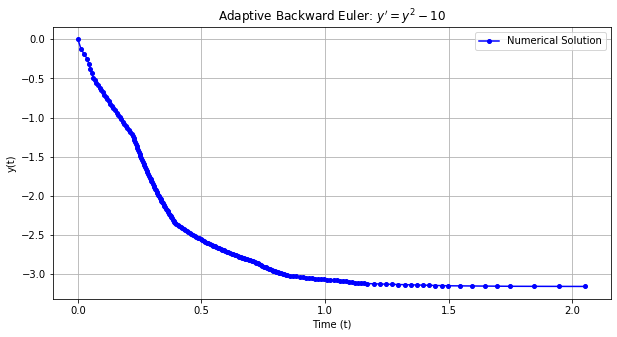

In [5]:
import matplotlib.pyplot as plt
t_vals, y_vals = backward_euler_adaptive(f, y0=0.0, t0=0.0, tf=2.0, h_init=0.1, tol=1e-4)
plt.figure(figsize=(10, 5))
plt.plot(t_vals, y_vals, 'b-o', markersize=4, label='Numerical Solution')
plt.xlabel("Time (t)")
plt.ylabel("y(t)")
plt.grid(True)
plt.legend()
plt.savefig('adaptive_euler_plot.png')